# COS30082 - Model Comparison

> Aston Lynch - 103964552

## 1. Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import keras as tfk
from sklearn.metrics import roc_auc_score, roc_curve

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1779270521.629911   31832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779270521.817568   31832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779270522.972284   31832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
IMG_SIZE = (96, 96)
PAIRS_FILE = '../data/verification_pairs_val.txt'
DATA_DIR = '../data'

In [3]:
preprocess_input = tfk.applications.mobilenet_v2.preprocess_input

## 2. Load Models

In [4]:
models = {
    'Classification': tfk.models.load_model('../checkpoints/classification_best.keras'),
    'Metric_Learning': tfk.models.load_model('../checkpoints/metric_best.keras'),
}

embedding_models = {}
for name, model in models.items():
    emb_output = model.get_layer('embedding').output
    embedding_models[name] = tfk.Model(inputs=model.input, outputs=emb_output, name=name)
    print(f"{name}: embedding_dim={emb_output.shape[-1]}")

I0000 00:00:1779270527.874144   31832 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12487 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Classification: embedding_dim=128
Metric_Learning: embedding_dim=128


## 3. Load Verification Pairs

In [5]:
pairs, labels = [], []
with open(PAIRS_FILE) as f:
    for line in f:
        img1, img2, label = line.strip().split()
        pairs.append((img1, img2))
        labels.append(int(label))

print(f"Pairs: {len(pairs)} | Positives: {sum(labels)} | Negatives: {len(labels) - sum(labels)}")

Pairs: 8805 | Positives: 4315 | Negatives: 4490


## 4. Eval Helpers

In [6]:
def load_image(path):
      img = tf.keras.utils.load_img(os.path.join(DATA_DIR, path), target_size=IMG_SIZE)
      img = tf.keras.utils.img_to_array(img)
      return preprocess_input(img)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

def evaluate_model(embedding_model, pairs, labels):
    unique_paths = list(set(p for pair in pairs for p in pair))
    images = np.array([load_image(p) for p in unique_paths])
    embeddings = embedding_model.predict(images, batch_size=64, verbose=1)
    embedding_map = {path: emb for path, emb in zip(unique_paths, embeddings)}

    cosine_scores, euclidean_scores, valid_labels = [], [], []
    for (img1, img2), label in zip(pairs, labels):
        e1, e2 = embedding_map[img1], embedding_map[img2]
        if np.linalg.norm(e1) < 1e-10 or np.linalg.norm(e2) < 1e-10:
            continue
        cosine_scores.append(cosine_similarity(e1, e2))
        euclidean_scores.append(-euclidean_distance(e1, e2))
        valid_labels.append(label)

    return {
        'auc_cosine': roc_auc_score(valid_labels, cosine_scores),
        'auc_euclidean': roc_auc_score(valid_labels, euclidean_scores),
        'roc_cosine': roc_curve(valid_labels, cosine_scores),
        'roc_euclidean': roc_curve(valid_labels, euclidean_scores),
    }

## 5. Run Eval

In [7]:
results = {}
for name, emb_model in embedding_models.items():
    print(f"\nEvaluating: {name}")
    results[name] = evaluate_model(emb_model, pairs, labels)
    print(f"  Cosine AUC: {results[name]['auc_cosine']:.4f}")
    print(f"  Euclidean AUC: {results[name]['auc_euclidean']:.4f}")


Evaluating: Classification


I0000 00:00:1779270548.807150  884475 cuda_dnn.cc:461] Loaded cuDNN version 92101


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
  Cosine AUC: 0.7023
  Euclidean AUC: 0.7713

Evaluating: Metric_Learning


I0000 00:00:1779270553.977652  884477 service.cc:153] XLA service 0x7f615414da30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779270553.977666  884477 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779270553.995444  884477 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
E0000 00:00:1779270555.408710  884477 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/147 ━━━━━━━━━━━━━━━━━━━━ 17:27 7s/step

I0000 00:00:1779270560.574552  884477 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/147 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

E0000 00:00:1779270562.571024  884475 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


147/147 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
  Cosine AUC: 0.7695
  Euclidean AUC: 0.7987


## 6. ROC Plot

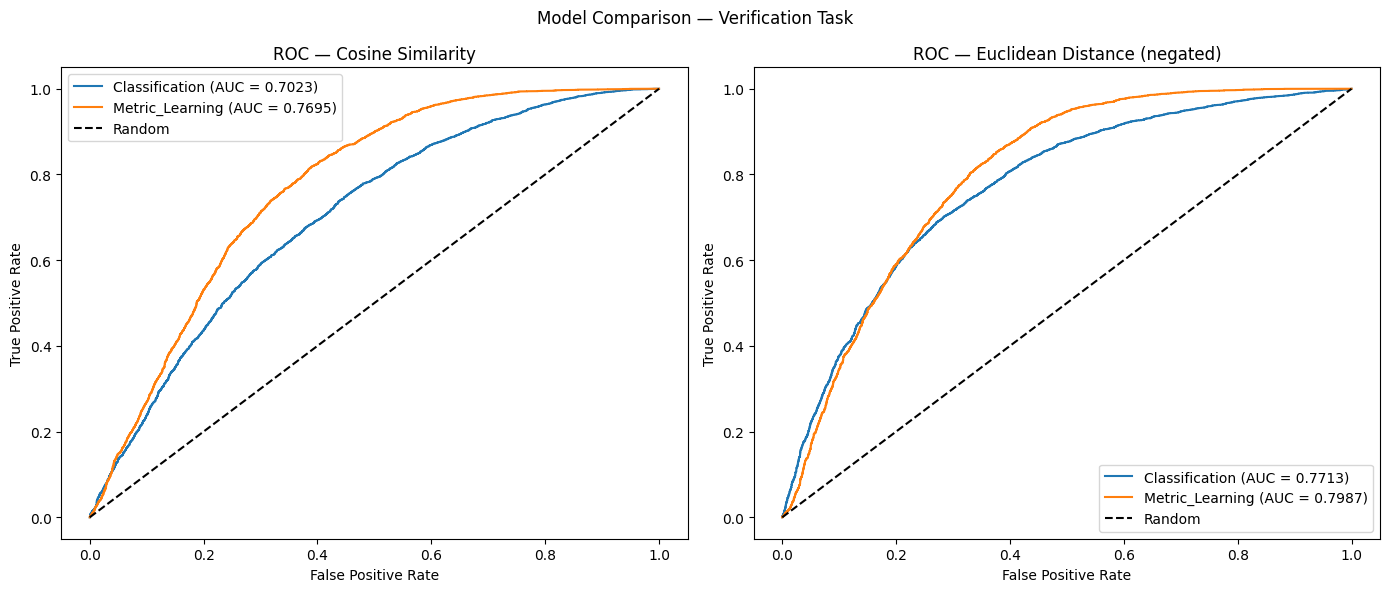

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ['Cosine Similarity', 'Euclidean Distance (negated)']
score_keys = ['roc_cosine', 'roc_euclidean']
auc_keys = ['auc_cosine', 'auc_euclidean']

for ax, title, score_key, auc_key in zip(axes, titles, score_keys, auc_keys):
    for name, res in results.items():
        fpr, tpr, _ = res[score_key]
        ax.plot(fpr, tpr, label=f"{name} (AUC = {res[auc_key]:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {title}')
    ax.legend()

plt.suptitle('Model Comparison — Verification Task')
plt.tight_layout()
plt.show()

## 7. Summary Table

In [9]:
print(f"{'Model':<25} {'Cosine AUC':>12} {'Euclidean AUC':>15}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<25} {res['auc_cosine']:>12.4f} {res['auc_euclidean']:>15.4f}")

Model                       Cosine AUC   Euclidean AUC
-------------------------------------------------------
Classification                  0.7023          0.7713
Metric_Learning                 0.7695          0.7987


In [10]:
fpr, tpr, thresholds = results['Metric_Learning']['roc_euclidean']
eer_idx = np.argmin(np.abs(fpr - (1 - tpr)))
print(f"EER threshold: {thresholds[eer_idx]:.4f}")

EER threshold: -0.6516
